In [1]:
from src.data_loader import load_data
from src.preprocess import prepare_data
from src.ML.train_NN_improved import (
    train_model,
    TextClassifier,
    DeepTextClassifier
)
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
from sklearn.metrics import classification_report

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 4)

DATA_PATH = '/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv'

In [2]:
# Plotting functions

def plot_results(class_to_idx, preds, labels, train_losses, test_accs, prefix='nn_'):
    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    # CLASSIFICATION REPORT
    
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=target_names, digits=4))

    idx_to_class = {i: cls for cls, i in class_to_idx.items()}
    target_names = [str(idx_to_class[i]) for i in sorted(idx_to_class.keys())]

    plot_confusion_matrix(labels, preds, target_names, prefix=prefix)
    plot_learning_curve(len(train_losses), train_losses, test_accs, prefix=prefix)
    plot_metrics_bar_chart(labels, preds, target_names, prefix=prefix)

In [3]:
# Load data
print('--- Loading and Preparing Data ---')
df = load_data(DATA_PATH)
print(df.shape)
df.head()

--- Loading and Preparing Data ---
Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...
(694, 2)


,Category,Text
0,0,Príjmy vedúcich policajných funkcionárov A ver...
1,0,Korekcie eurofondov Financie získava späť Euró...
2,0,Súd potvrdil pokutu pre banku Penty Najvyšší s...
3,0,Ako vykradnúť banku: Ekonómovia zostavili vzor...
4,0,Podvodník prehovoril o nekalých praktikách: Ži...


Simple Feed Forward NN — class weights
Input dimension: 3000
Input dimension for NN: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.8036    0.8911    0.8451       101
           1     0.5926    0.4211    0.4923        38

    accuracy                         0.7626       139
   macro avg     0.6981    0.6561    0.6687       139
weighted avg     0.7459    0.7626    0.7486       139



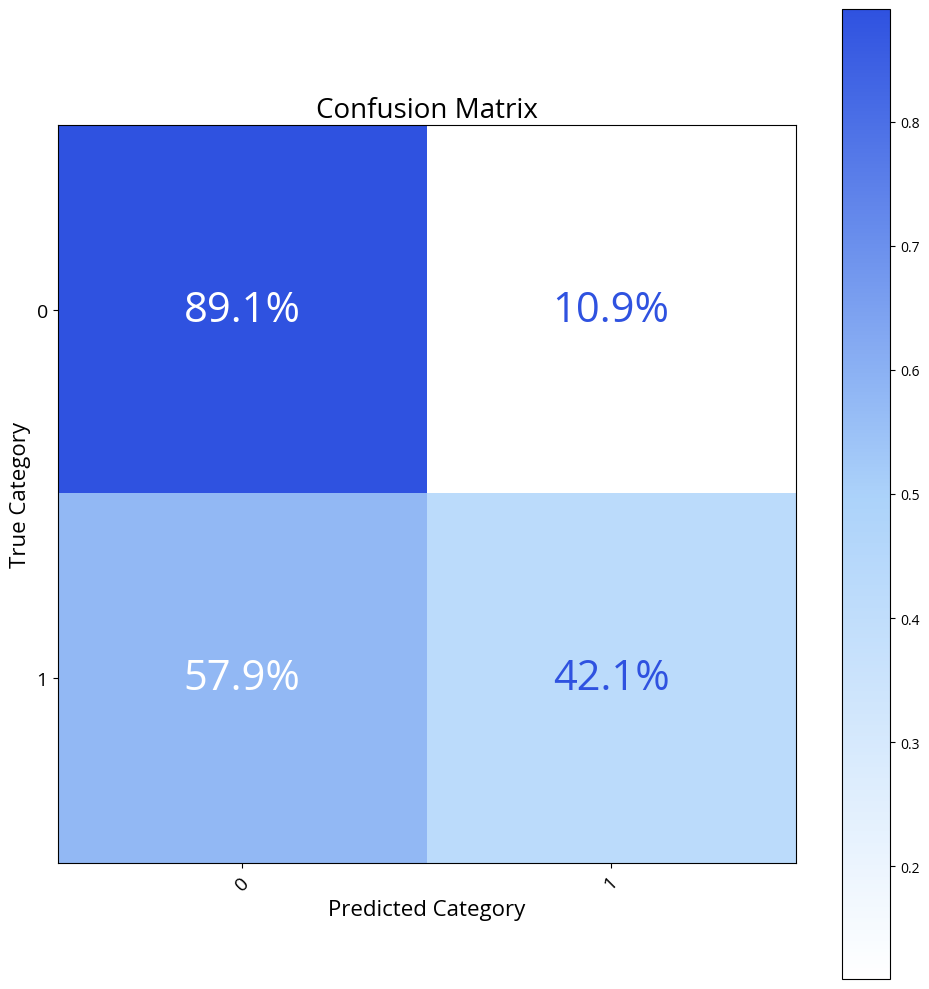

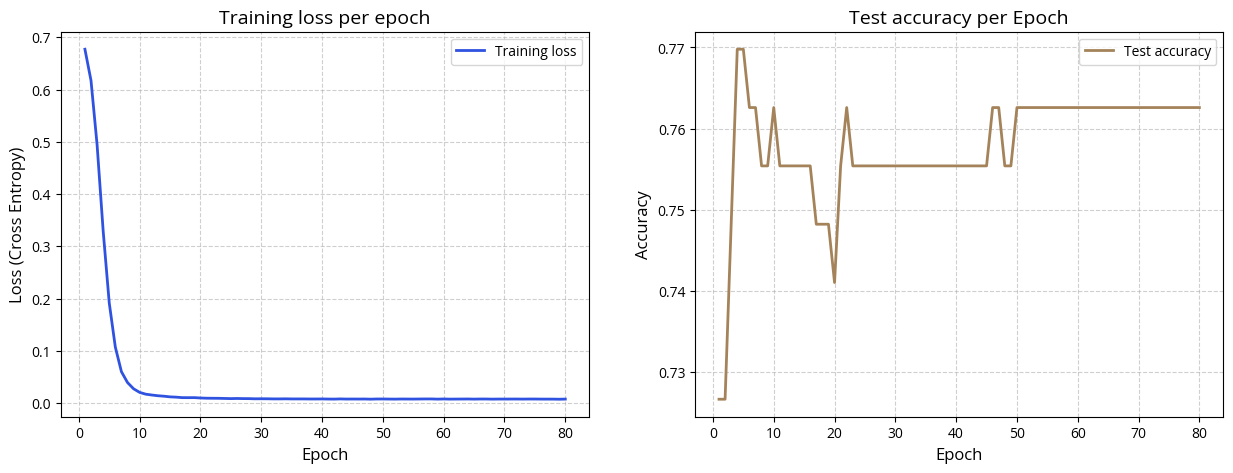

<Figure size 600x400 with 0 Axes>

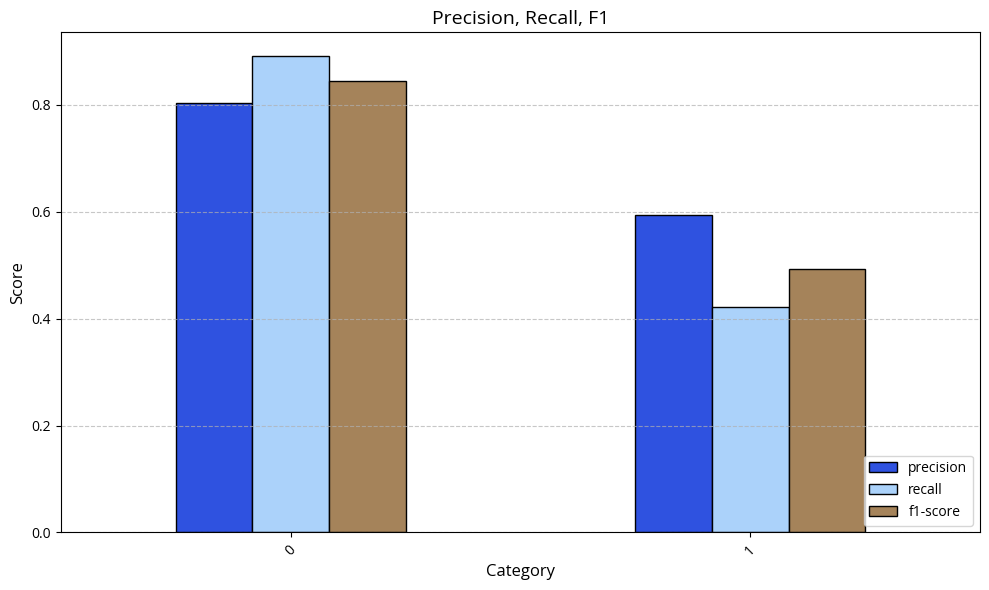

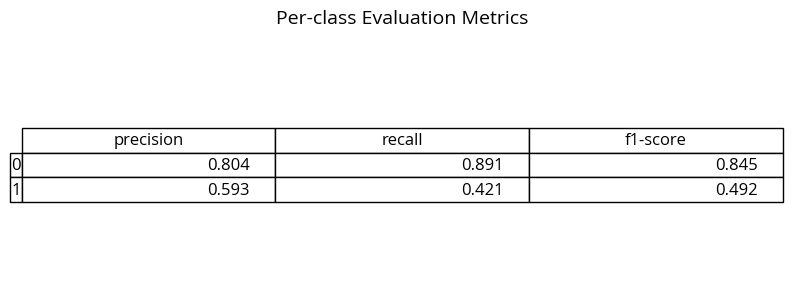

In [4]:
#Simple Feed Forward NN — TF-IDF + class weights
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Simple Feed Forward NN — class weights')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=80,
    lr=1e-3,
    class_weights=True,
    use_scheduler=True
)
print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Deep Feed Forward NN — class weights
Input dimension: 3000
Input dimension for NN: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.7830    0.8218    0.8019       101
           1     0.4545    0.3947    0.4225        38

    accuracy                         0.7050       139
   macro avg     0.6188    0.6083    0.6122       139
weighted avg     0.6932    0.7050    0.6982       139



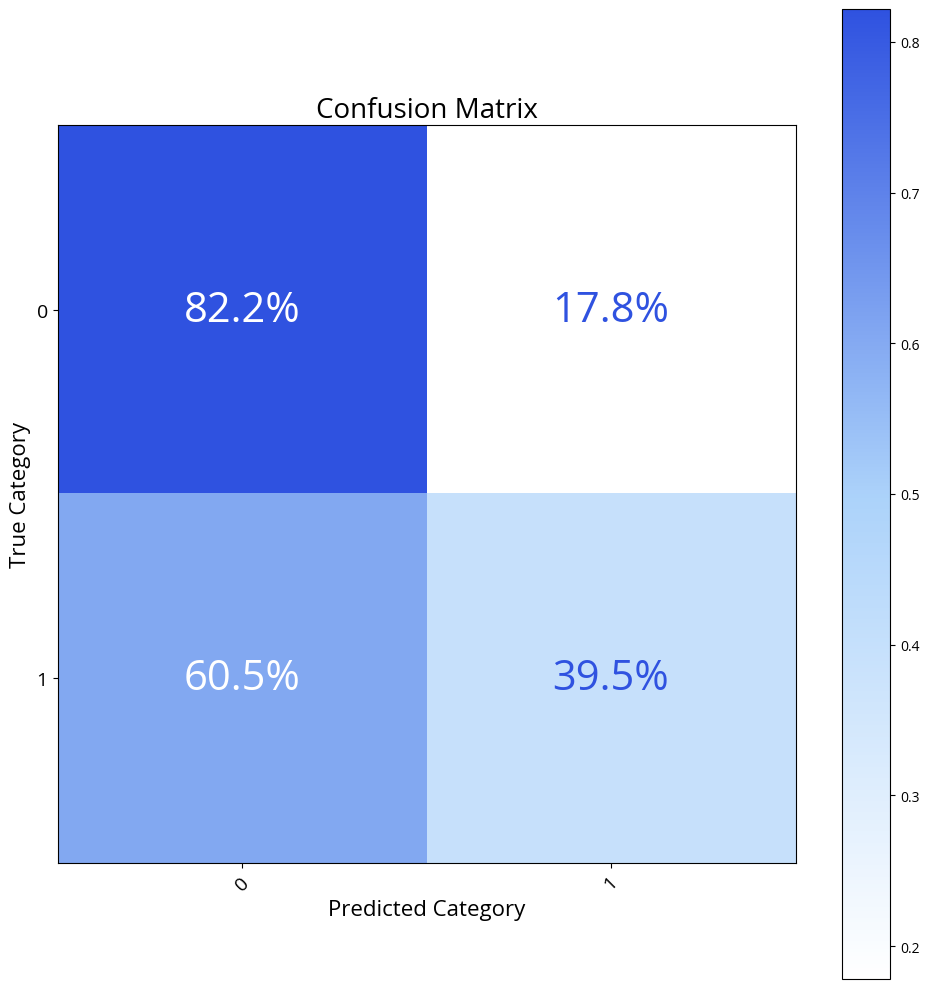

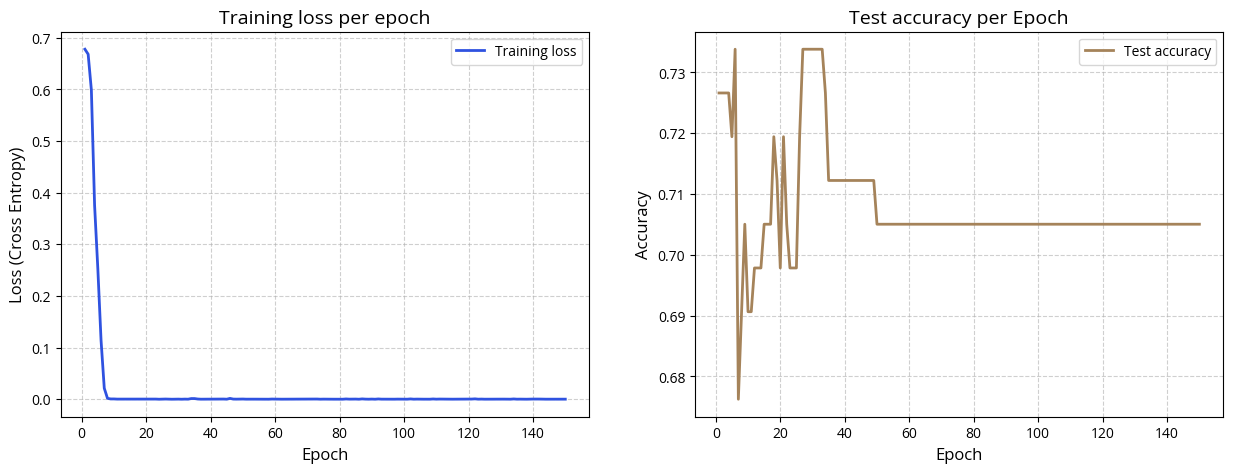

<Figure size 600x400 with 0 Axes>

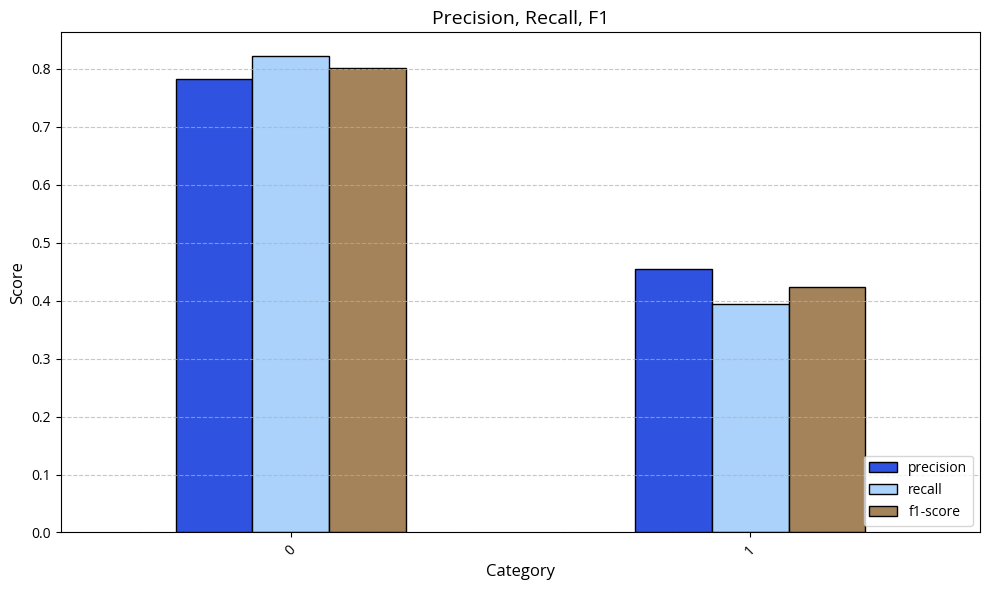

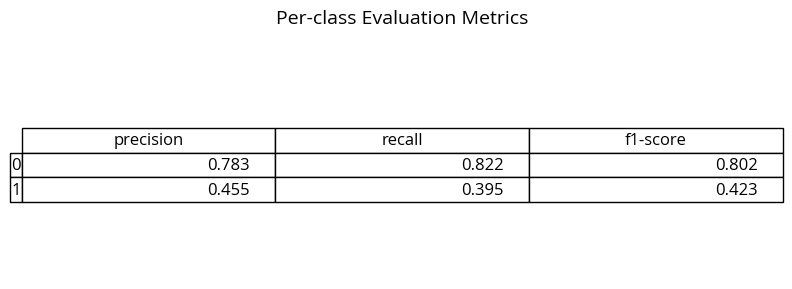

In [5]:
# Deep Feed Forward NN — TF-IDF + class weights
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Deep Feed Forward NN — class weights')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=1e-3,
    class_weights=True,
    use_scheduler=True
)

print("Input dimension for NN:", X_train.shape[1])

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Simple Feed Forward NN — weighted sampler
Class counts: [404 151]
Sample weights per class: [0.00247525 0.00662252]
Input dimension: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.8919    0.6535    0.7543       101
           1     0.4615    0.7895    0.5825        38

    accuracy                         0.6906       139
   macro avg     0.6767    0.7215    0.6684       139
weighted avg     0.7742    0.6906    0.7073       139



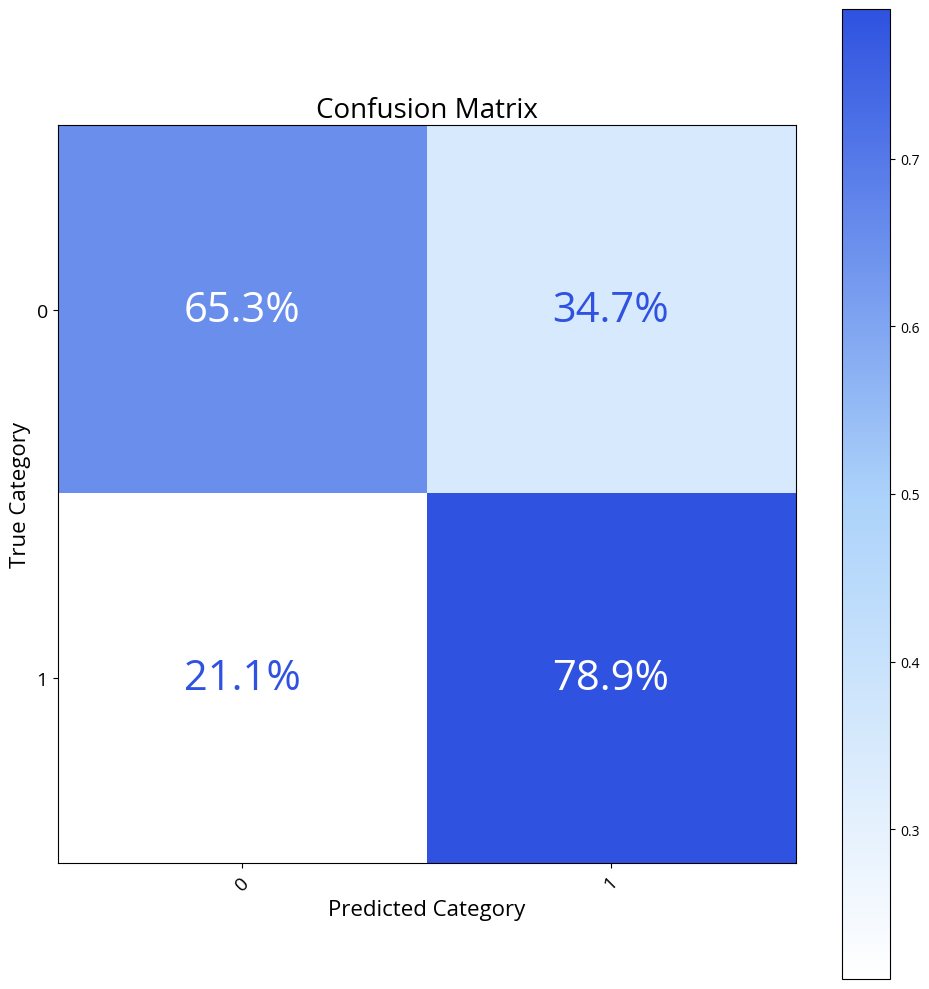

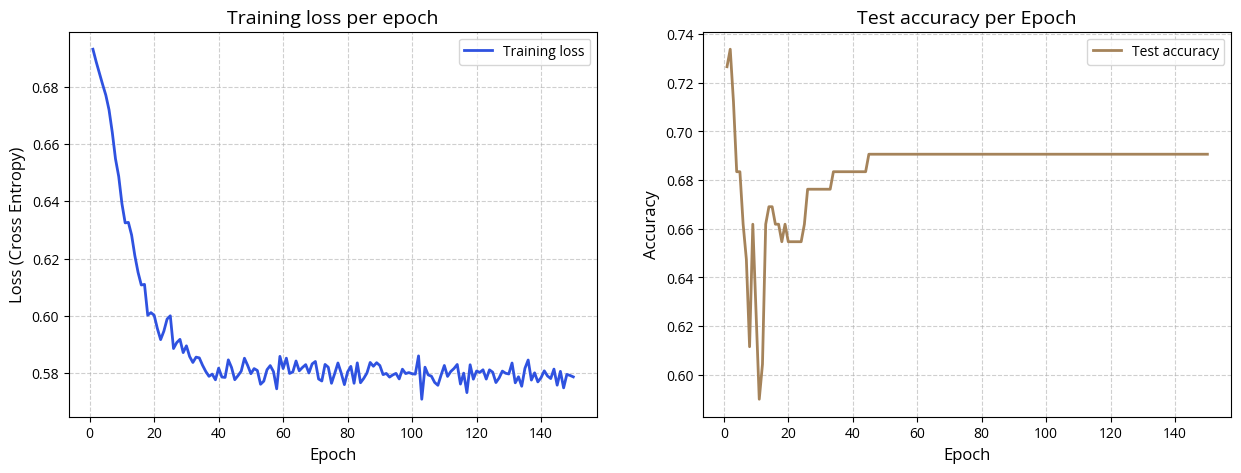

<Figure size 600x400 with 0 Axes>

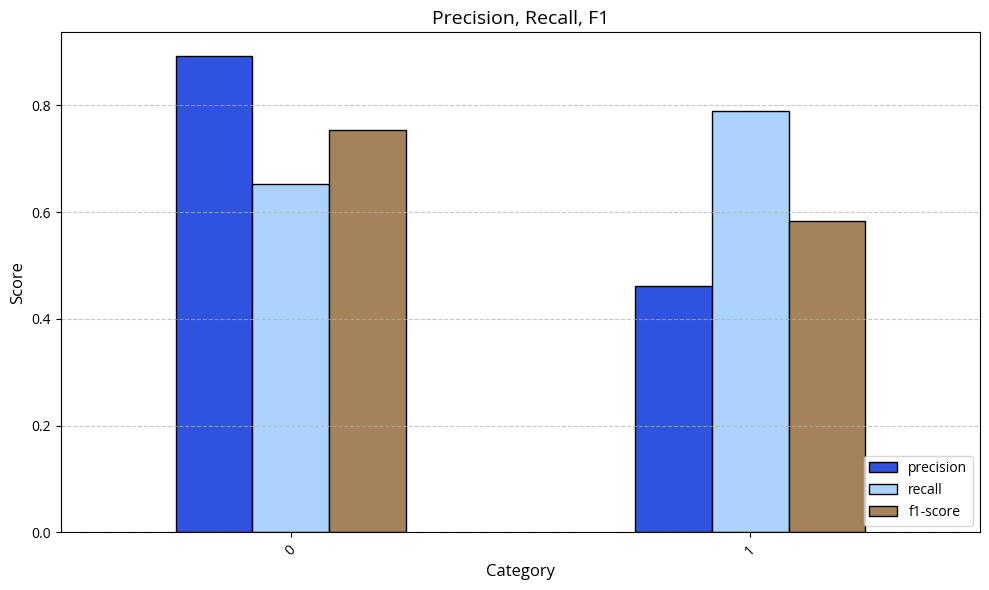

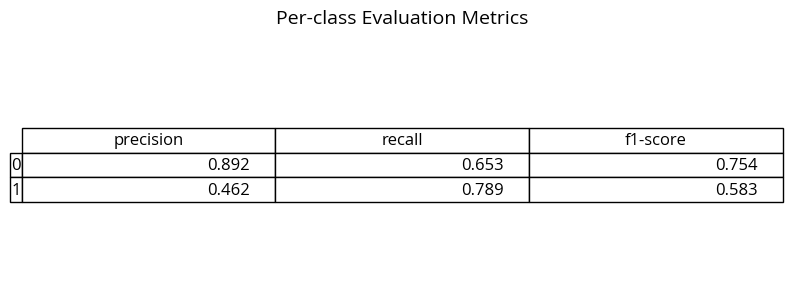

In [6]:
#Simple Feed Forward NN — weighted sampler
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Simple Feed Forward NN — weighted sampler')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=150,
    lr=8e-5,
    sampler='weighted',
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

Deep Feed Forward NN — weighted sampler
Class counts: [404 151]
Sample weights per class: [0.00247525 0.00662252]
Input dimension: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.8537    0.6931    0.7650       101
           1     0.4561    0.6842    0.5474        38

    accuracy                         0.6906       139
   macro avg     0.6549    0.6886    0.6562       139
weighted avg     0.7450    0.6906    0.7055       139



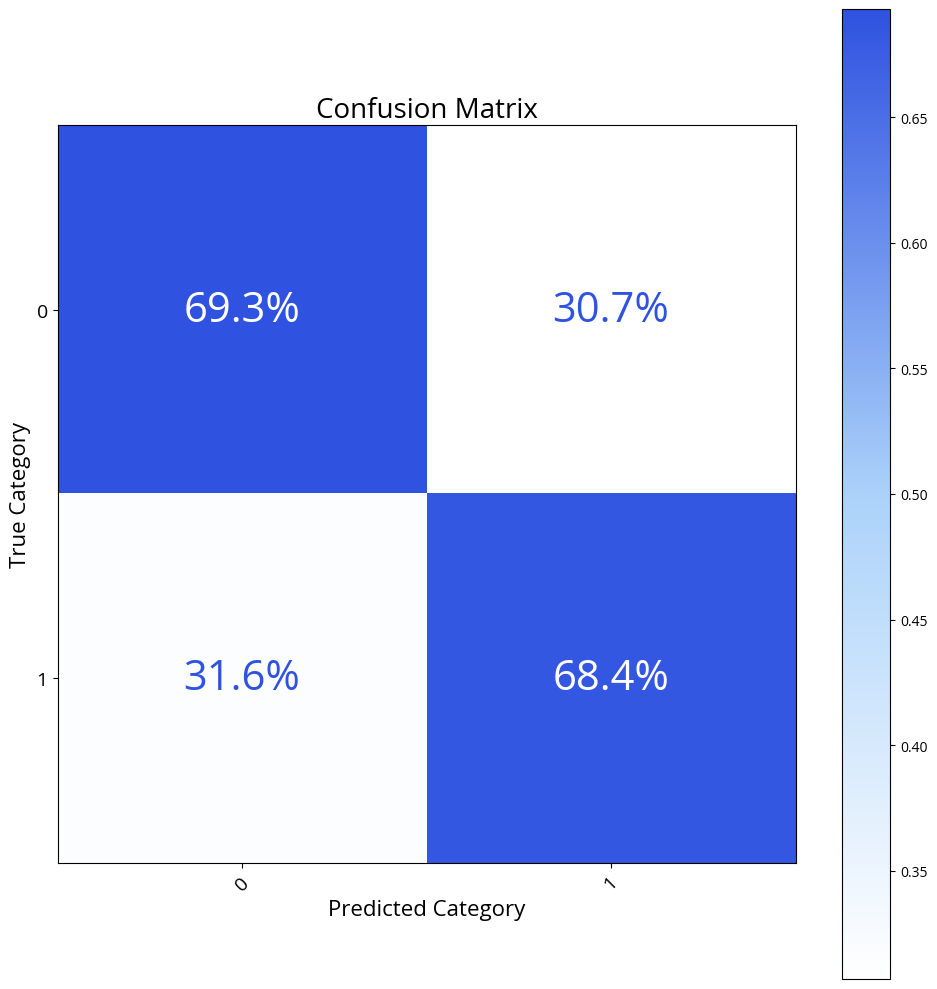

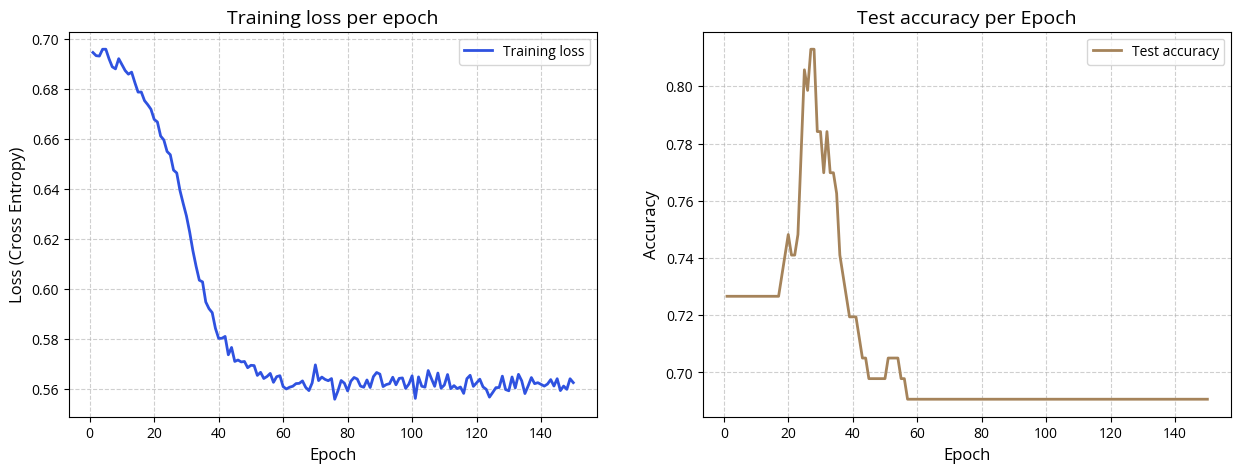

<Figure size 600x400 with 0 Axes>

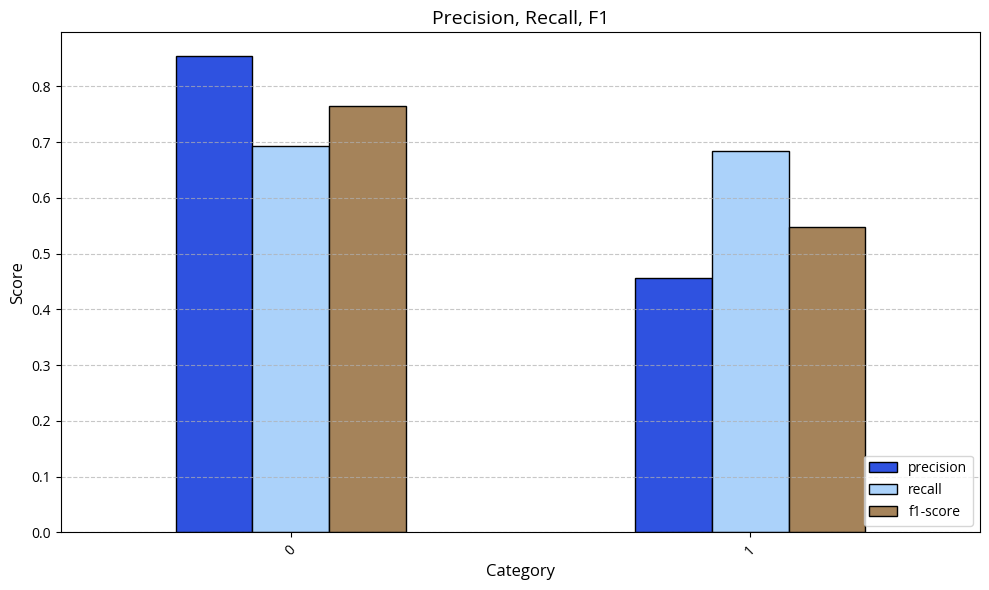

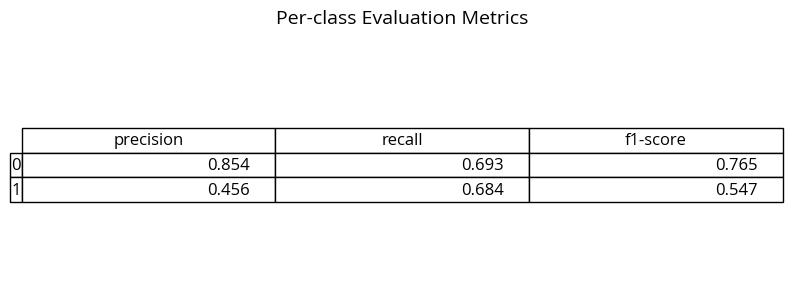

In [7]:
#Deep Feed Forward NN — weighted sampler
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print('Deep Feed Forward NN — weighted sampler')

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=8e-5,
    sampler='weighted',
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))


Input dimension: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.7876    0.8812    0.8318       101
           1     0.5385    0.3684    0.4375        38

    accuracy                         0.7410       139
   macro avg     0.6630    0.6248    0.6346       139
weighted avg     0.7195    0.7410    0.7240       139



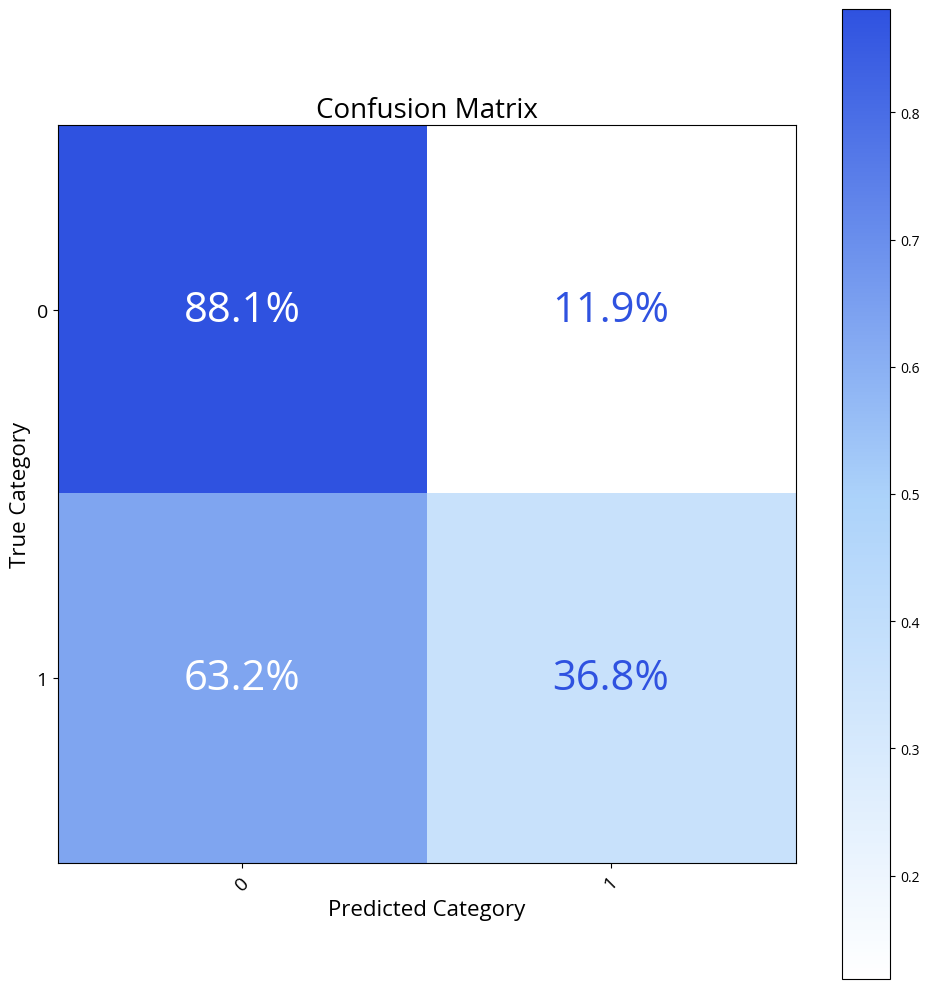

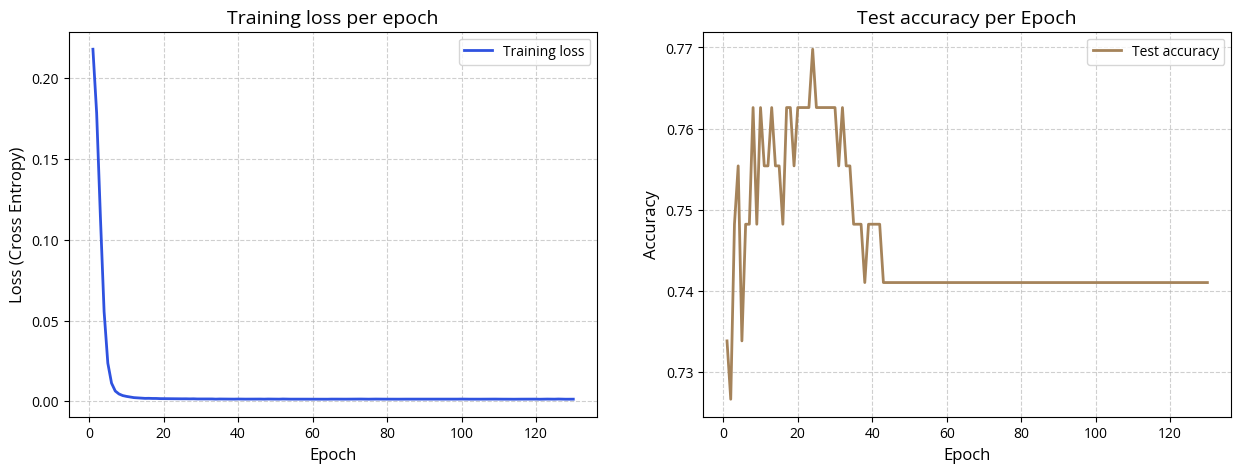

<Figure size 600x400 with 0 Axes>

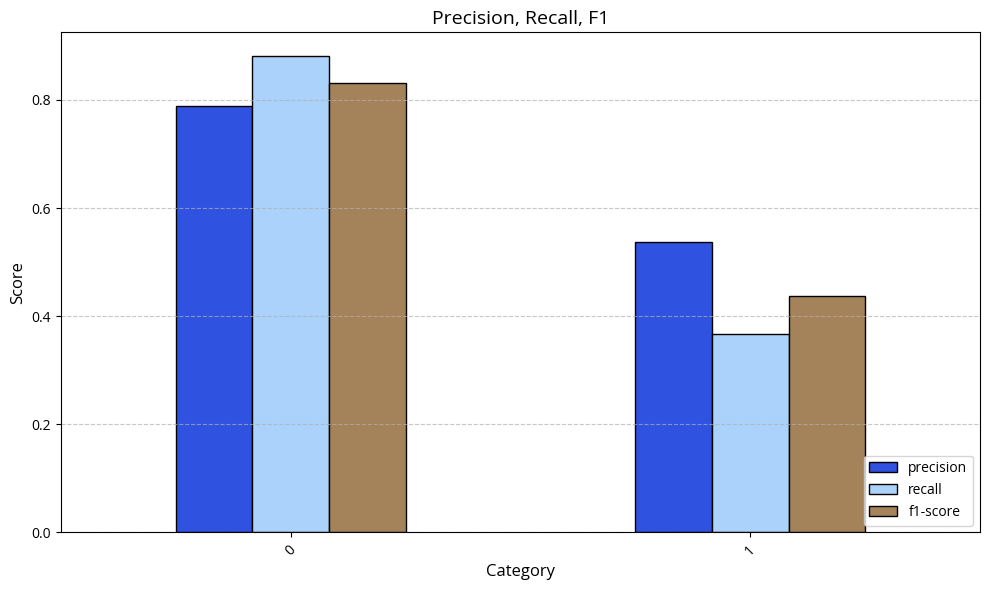

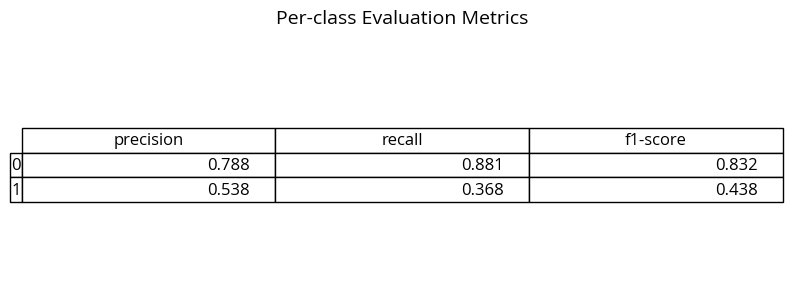

In [8]:
#Simple Feed Forward NN — Focal Loss
import torch
from src.ML.train_NN_improved import FocalLoss

X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

alpha = torch.tensor([1.0, 2.0])  # higher weight on minority class (index 1)

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={'hidden_dim': 256},
    epochs=130,
    lr=1e-3,
    loss_fn=FocalLoss(alpha=alpha, gamma=2),
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)

/home/xkubanova_126831/bakalarka/nbs_binary/src/ML/train_NN_improved.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))


Input dimension: 3000

Classification Report:
              precision    recall  f1-score   support

           0     0.7540    0.9406    0.8370       101
           1     0.5385    0.1842    0.2745        38

    accuracy                         0.7338       139
   macro avg     0.6462    0.5624    0.5558       139
weighted avg     0.6951    0.7338    0.6832       139



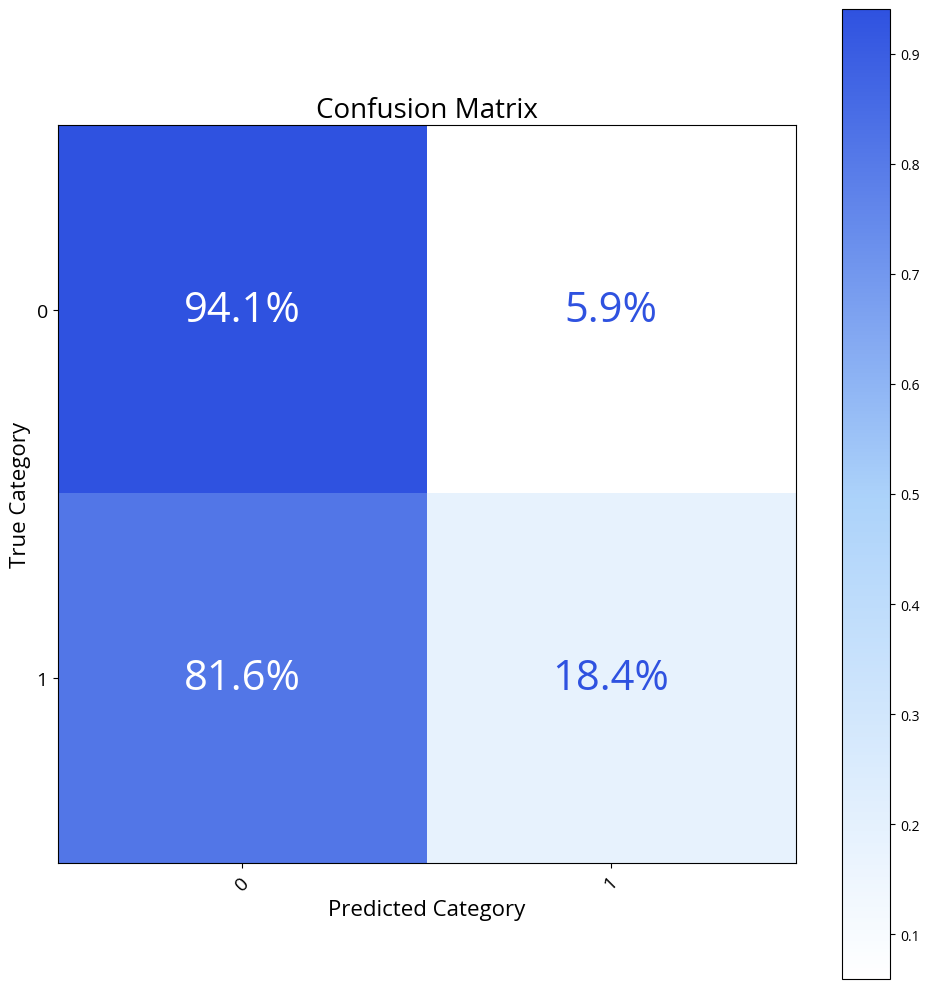

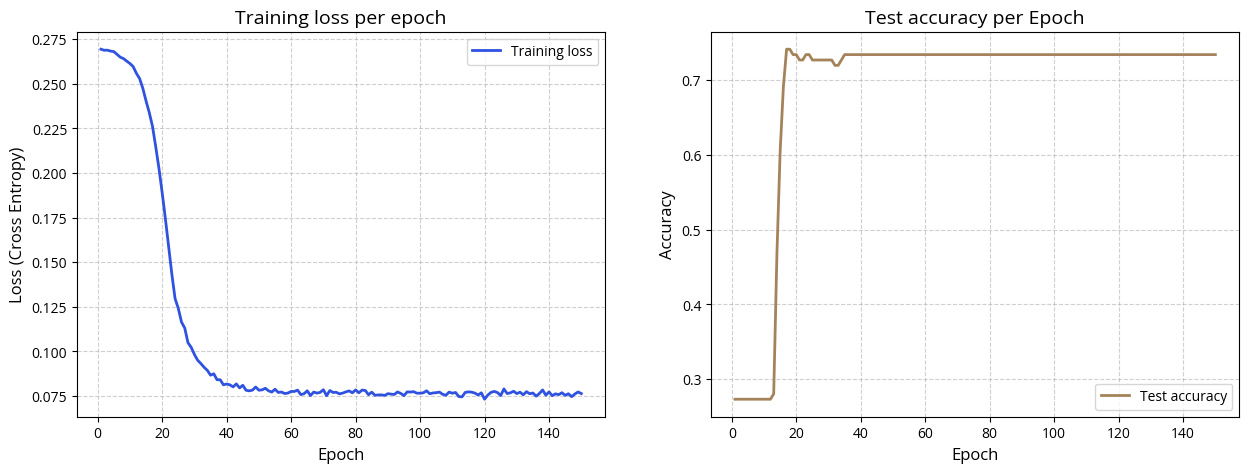

<Figure size 600x400 with 0 Axes>

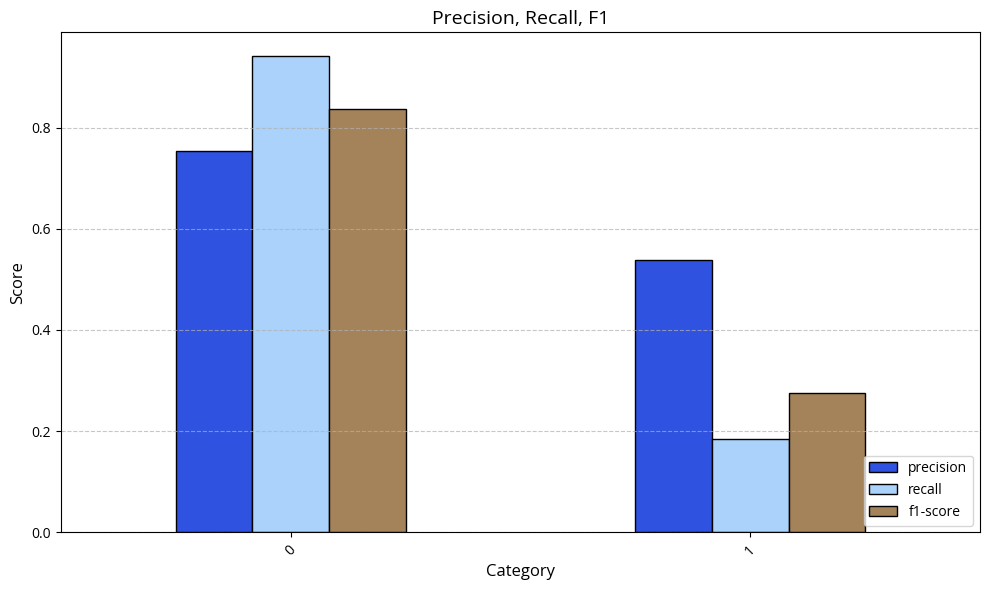

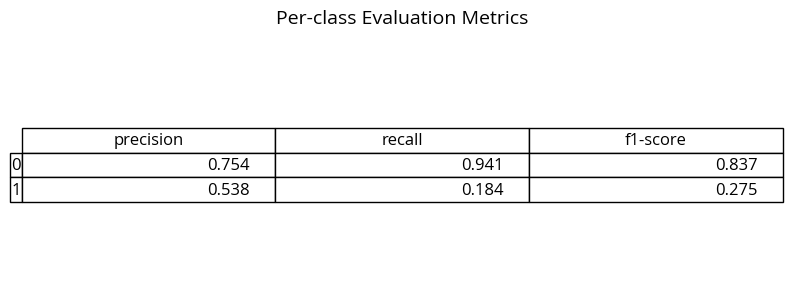

In [9]:
## Deep Feed Forward NN — Focal Loss
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

alpha = torch.tensor([1.0, 3.0])

model, class_to_idx, preds, labels, train_losses, test_accs = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={'hidden_dims': [256, 128, 64, 32]},
    epochs=150,
    lr=1e-4,
    loss_fn=FocalLoss(alpha=alpha, gamma=2),
    use_scheduler=True
)

plot_results(class_to_idx, preds, labels, train_losses, test_accs)